### 1. Создание схемы нейронной сети согласно варианту таблицы

Рассмотрим двухслойную нейронную сеть следующей структуры:
- **Входной слой:** 1 вход ($x_1$).
- **Скрытый слой (первый):** 28 нейронов, функция активации — ReLU: $P(S) = \max(0, S)$.
- **Выходной слой (второй):** 1 нейрон, функция активации — Leaky ReLU: $Y(S) = \begin{cases} S, & S \ge 0,\\ \alpha S, & S < 0, \quad (0 < \alpha \ll 1) \end{cases}$

![Neuro.png](../images/Neuro.png)

### 2. Создание математической модели нейронной сети согласно варианту

### 1. Первый (скрытый) слой

В этом слое каждый нейрон $j$ вычисляет взвешенную сумму входов $S_j^{(1)}$, а затем применяет к ней сигмоидную функцию активации для получения выхода $P_j$.

**Развернутая запись для каждого нейрона:**

**Первый нейрон скрытого слоя ($j=1$):**
$$ S_1^{(1)} = x_1 \cdot w_{11}^{(1)}  $$
$$ P_1 = \max(0, S_1^{(1)}) $$

**Второй нейрон скрытого слоя ($j=2$):**
$$ S_2^{(1)} = x_1 \cdot w_{21}^{(1)} $$
$$ P_2 = \max(0, S_2^{(1)}) $$

**n-й нейрон скрытого слоя ($j=n$):**
$$ S_n^{(1)} = x_1 \cdot w_{n1}^{(1)} $$
$$ P_n = \max(0, S_n^{(1)}) $$

**Двадцать восьмой нейрон скрытого слоя ($j=28$):**
$$ S_{28}^{(1)} = x_1 \cdot w_{28,1}^{(1)}  $$
$$ P_{28} = \max(0, S_{28}^{(1)}) $$

---

**Обобщенная формула для первого слоя:**

Для любого нейрона $j$ ($j = 1 \dots 28$) скрытого слоя:

$$ S_j^{(1)} =  x\cdot w_{j}^{(1)} $$

$$ P_j = \max(0, S_j^{(1)}) $$

где:
- $i$ — индекс входа ($i = 1$);
- $j$ — индекс нейрона в скрытом слое ($j = 1 \dots 28$);
- $w_{ji}^{(1)}$ — вес связи, идущей от $i$-го входа к $j$-му нейрону скрытого слоя.

---

### 2. Второй (выходной) слой

В этом слое каждый нейрон $q$ вычисляет взвешенную сумму выходов скрытого слоя $S_q^{(2)}$, а затем применяет пороговую функцию активации.

**Развернутая запись для каждого выхода:**

**Первый выходной нейрон ($q=1$):**
$$ S_1^{(2)} = P_1 \cdot w_{11}^{(2)} $$
$$Y_1(S) = \begin{cases} S, & S \ge 0,\\ \alpha S, & S < 0, \quad (0 < \alpha \ll 1) \end{cases}$$

**Второй выходной нейрон**
$$ S_2^{(2)} = P_2 \cdot w_{12}^{(2)} $$
$$Y_2(S) = \begin{cases} S, & S \ge 0,\\ \alpha S, & S < 0, \quad (0 < \alpha \ll 1) \end{cases}$$

**27 выходной нейрон**
$$ S_{27}^{(2)} = P_{27} \cdot w_{1,27}^{(2)} $$
$$Y_{27}(S) = \begin{cases} S, & S \ge 0,\\ \alpha S, & S < 0, \quad (0 < \alpha \ll 1) \end{cases}$$
**28 выходной нейрон**
$$ S_{28}^{(2)} = P_{28} \cdot w_{1,28}^{(2)} $$
$$Y_{28}(S) = \begin{cases} S, & S \ge 0,\\ \alpha S, & S < 0, \quad (0 < \alpha \ll 1) \end{cases}$$
---
---

**Обобщенная формула для второго слоя:**

Для  выхода $q$ ($q = 1$) выходного слоя:

$$ S_q^{(2)} = \sum_{j=1}^{28} P_j \cdot w_{qj}^{(2)} $$

$$Y_q = \begin{cases} S_q^{(2)}, & S_q^{(2)} \ge 0,\\ \alpha S_q^{(2)}, & S_q^{(2)} < 0, \quad (0 < \alpha \ll 1) \end{cases}$$

где:
- $j$ — индекс нейрона скрытого слоя ($j = 1 \dots 28$);
- $q$ — индекс нейрона выходного слоя ($q = 1 $);
- $w_{qj}^{(2)}$ — вес связи, идущей от $j$-го скрытого нейрона к $q$-му выходному.

---

**Итоговая формула всей сети (в общем виде):**

Выход $Y_q$ вычисляется как:

$$Y_q = \begin{cases} \sum_{j=1}^{28} \max(0,  x\cdot w_{j}^{(1)} ) \cdot w_{qj}^{(2)} , & \sum_{j=1}^{28} \max(0,  x\cdot w_{j}^{(1)} ) \cdot w_{qj}^{(2)}  \ge 0,\\ \alpha \sum_{j=1}^{28} \max(0,  x\cdot w_{j}^{(1)} ) \cdot w_{qj}^{(2)} , & \sum_{j=1}^{28} \max(0,  x\cdot w_{j}^{(1)} ) \cdot w_{qj}^{(2)}  < 0, \quad (0 < \alpha \ll 1) \end{cases}$$
где $q = 1$.

## 3. Моделирование нейронной сети (практическое задание)

В этом разделе мы реализуем на Python модель двухслойной нейронной сети согласно варианту.

**Наша задача:**
1. Создать функцию `Neuron`, которая моделирует прямой проход сигнала через сеть (вход → скрытый слой → выход).
2. Создать функцию `Wes`, которая запускает сеть с тремя различными диапазонами случайных весов:
   - **$[-1; 0]$** — только отрицательные (тормозящие) связи;
   - **$[-1; 1]$** — смешанные веса;
   - **$[0; 1]$** — только положительные (возбуждающие) связи.
3. Подать на вход сети тестовые сигналы (линейный, пороговый, синусоидальный) и построить графики выходов.


## 3. Моделирование нейронной сети (практическое задание)

В этом разделе мы реализуем на Python модель двухслойной нейронной сети согласно варианту.

**Наша задача:**
1. Создать функцию `Neuron`, которая моделирует прямой проход сигнала через сеть (вход → скрытый слой → выход).
2. Создать функцию `Wes`, которая запускает сеть с тремя различными диапазонами случайных весов:
   - **$[-1; 0]$** — только отрицательные (тормозящие) связи;
   - **$[-1; 1]$** — смешанные веса;
   - **$[0; 1]$** — только положительные (возбуждающие) связи.
3. Подать на вход сети тестовые сигналы (линейный, пороговый, синусоидальный) и построить графики выходов.


In [7]:
# Импорты
import random
import numpy as np
import matplotlib.pyplot as plt

# Диапазоны весов (базовый случай)
a = -1
b = 1

In [13]:
def Neuron(WS, WV, Xx, vx, weight_label=""):
    """
    Прямой проход двухслойной сети:
    Xx: (1, T)   входы (1 сигнал на T шагов времени)
    WS: (28, 1)   веса вход -> скрытый (28 скрытых нейронов)
    WV: (1, 28)   веса скрытый -> выход (1 выходной нейрон)
    weight_label: подпись диапазона весов для заголовка
    """
    Y = np.zeros(1)
    S = np.zeros(28)
    P = np.zeros(28)
    s = np.zeros(1)
    y = np.zeros((1, Xx.shape[1]))
    a = 0.5
    for t in range(0, Xx.shape[1]):
        Y = np.zeros(1)
        S = np.zeros(28)
        P = np.zeros(28)
        s = np.zeros(1)

        # Скрытый слой
        for i in range(0, 28):
            for j in range(0, 1):
                S[i] = Xx[j, t] * WS[i, j] + S[i]
            P[i] = max(0,S[i])

        # Выходной слой
        for i in range(0, 1):
            for j in range(0, 28):
                s[i] = P[j] * WV[i, j] + s[i]
                if s[i] >= 0:
                  Y[i] = s[i]
                else:
                  Y[i] = a*s[i]
            y[i, t] = Y[i]

    # Визуализация выхода
    plt.figure(figsize=(10, 6))
    plt.grid(alpha=0.3)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('y', fontsize=12)
    plt.title(f'Выходы нейронной сети | {weight_label}', fontsize=13, fontweight='bold')
    plt.plot(vx, y[0], linewidth=2, label='Y1', marker='o', markersize=4)
    plt.legend(fontsize=11)
    plt.tight_layout()

In [14]:
def Wes(Xx, vx, a, b):
    # [0, b] - только положительные веса
    WS = np.random.uniform(0, b, (28, 1))
    WV = np.random.uniform(0, b, (1, 28))
    Neuron(WS, WV, Xx, vx, weight_label=f"Диапазон весов: [0, {b}]")

    # [a, 0] - только отрицательные веса
    WS = np.random.uniform(a, 0, (28, 1))
    WV = np.random.uniform(a, 0, (1, 28))
    Neuron(WS, WV, Xx, vx, weight_label=f"Диапазон весов: [{a}, 0]")

    # [a, b] - смешанные веса
    WS = np.random.uniform(a, b, (28, 1))
    WV = np.random.uniform(a, b, (1, 28))
    Neuron(WS, WV, Xx, vx, weight_label=f"Диапазон весов: [{a}, {b}]")

### 3.2. Подготовка и визуализация входных данных

Сформируем тестовые сигналы, которые будем подавать на вход сети:
1.  **Линейный сигнал** (y = kx + b)
2.  **Пороговый сигнал** (ступенька)
3.  **Синусоидальный сигнал** (y = sin(x))

Построим графики этих входных сигналов, чтобы видеть, с чем будет работать наша нейронная сеть.

In [15]:
k = random.uniform(-10, 10)

Xx = np.random.uniform(0, 1, (3, 20))
vx = np.linspace(-20, 20, 20)

for i in range(0, 20):
    Xx[0, i] = vx[i] * k + 3
    Xx[1, i] = 0.2 if vx[i] < 0 else 1
    Xx[2, i] = np.sin(vx[i])

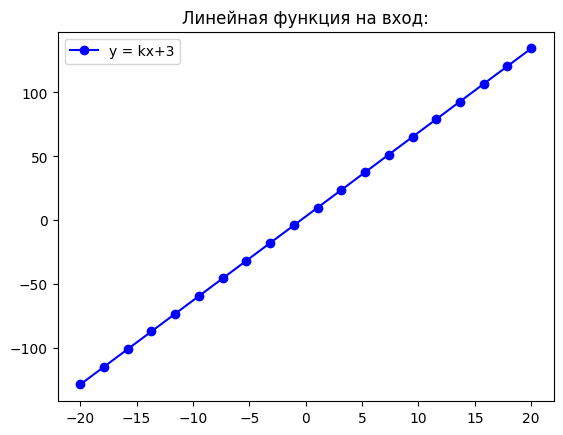

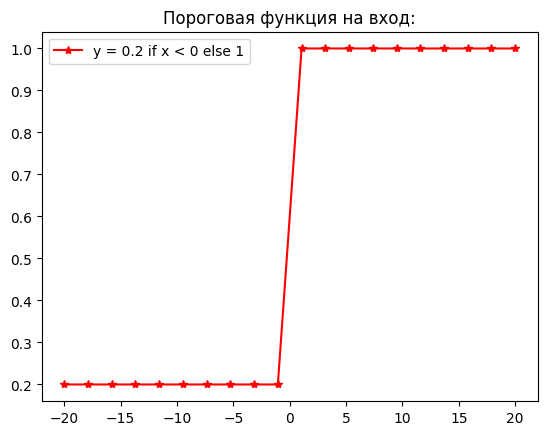

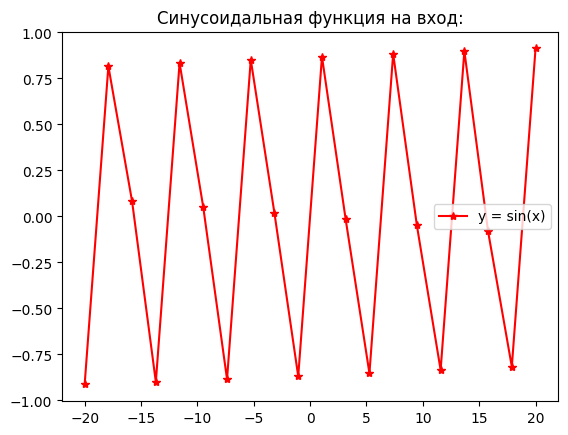

In [16]:
plt.figure()
plt.title('Линейная функция на вход:')
plt.plot(vx, Xx[0], 'bo-', label='y = kx+3')
plt.legend()

plt.figure()
plt.title('Пороговая функция на вход:')
plt.plot(vx, Xx[1], 'r*-', label='y = 0.2 if x < 0 else 1')
plt.legend()

plt.figure()
plt.title('Синусоидальная функция на вход:')
plt.plot(vx, Xx[2], 'r*-', label='y = sin(x)')
plt.legend()


### 3.3. Эксперименты с весами

Теперь проведем серию экспериментов, меняя диапазоны случайных весов. Это позволит увидеть, как начальная инициализация влияет на работу сети.

#### 3.3.1. Базовый эксперимент

Запустим моделирование для трех диапазонов весов. На графиках будут показаны выходы сети ($Y_1, Y_2$) для каждого случая.

Обратите внимание, как меняется характер кривых в зависимости от знака весов. Напишите вывод.

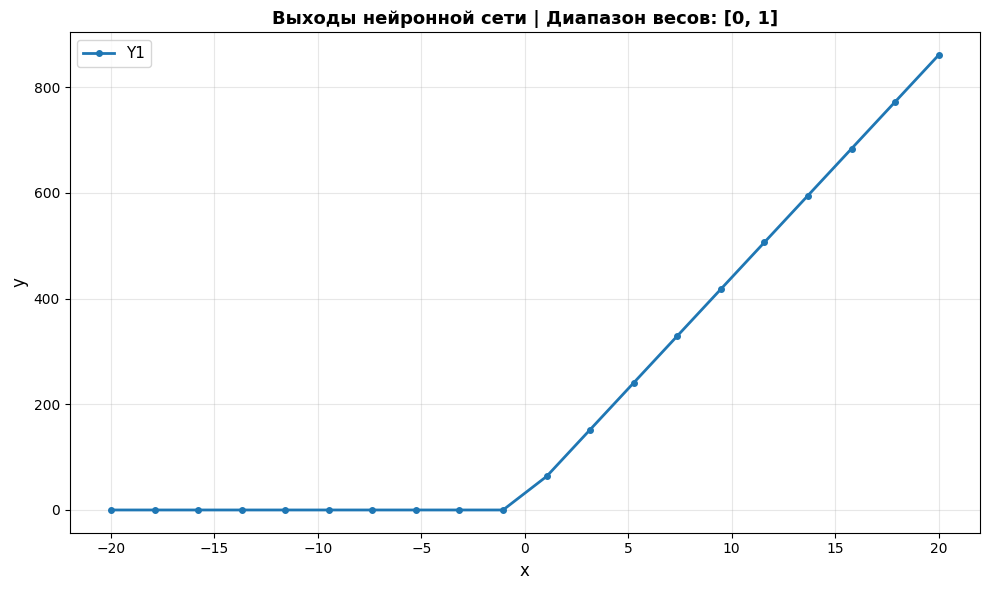

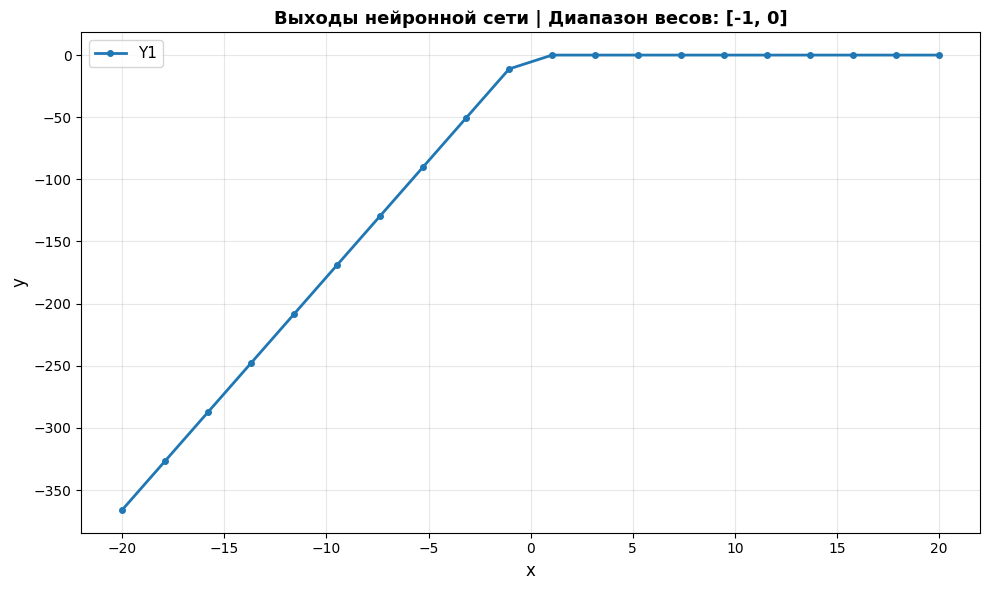

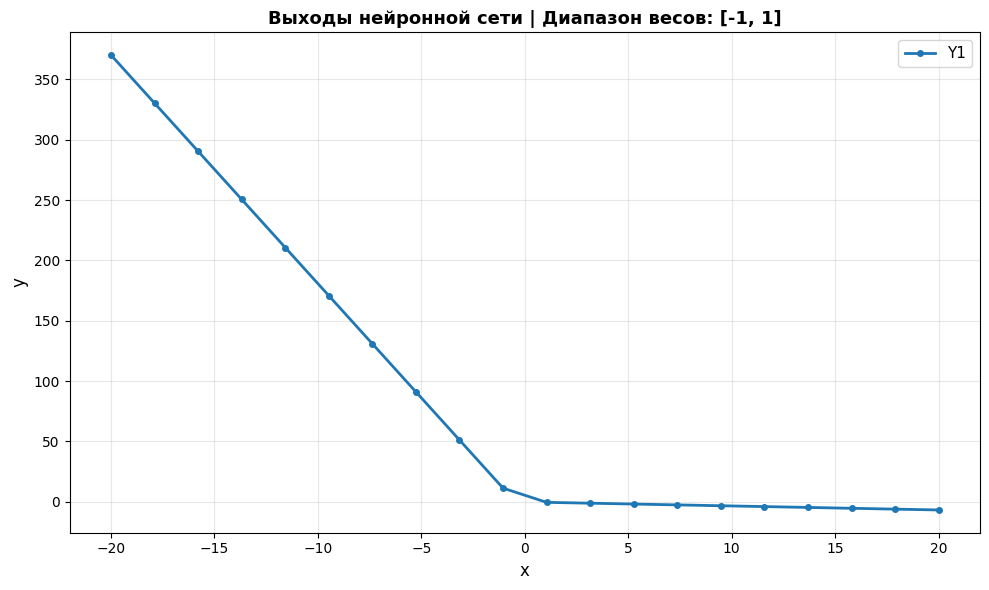

In [17]:
# Базовые диапазоны
Wes(Xx, vx, a, b)
plt.show()

**Вывод:** При стандартных диапазонах весов выходные сигналы сети имеют выраженную нелинейную форму. Знак весов напрямую влияет на направление изменения выходов: при положительных весах функция возрастает, при отрицательных - убывает. При смешанном диапазоне [−1;1] наблюдается более сложный характер кривых из-за комбинации положительных и отрицательных коэффициентов. Сеть демонстрирует устойчивое, но не чрезмерно резкое изменение выходов.

#### 3.3.2. Эксперимент с уменьшением весов в 10 раз

Запустите код ниже. Веса уменьшатся в 10 раз (диапазоны $[-0.1; 0]$, $[-0.1; 0.1]$, $[0; 0.1]$).

Обратите внимание, как меняется характер кривых в зависимости от изменения весов. Напишите вывод.

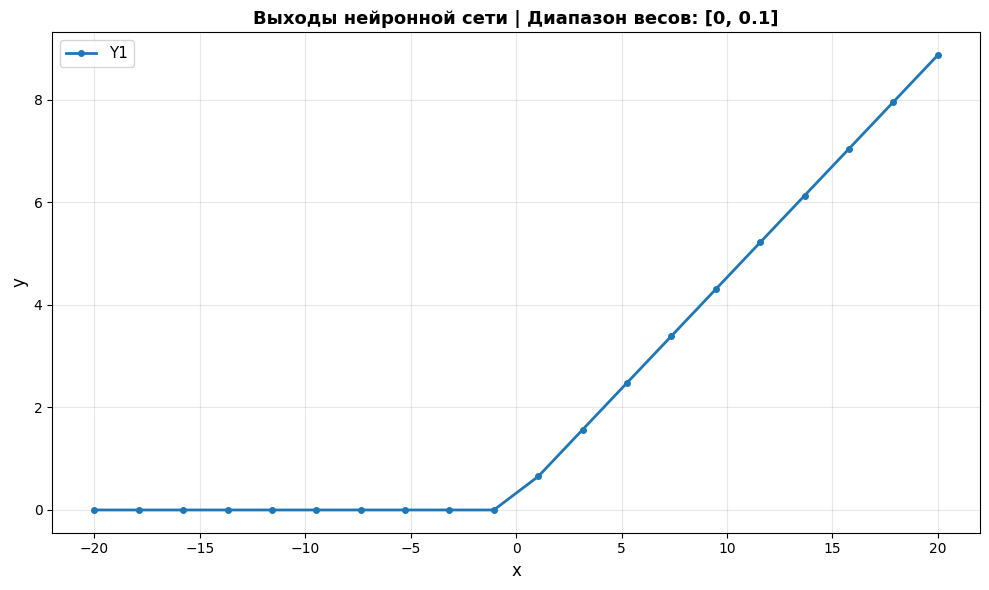

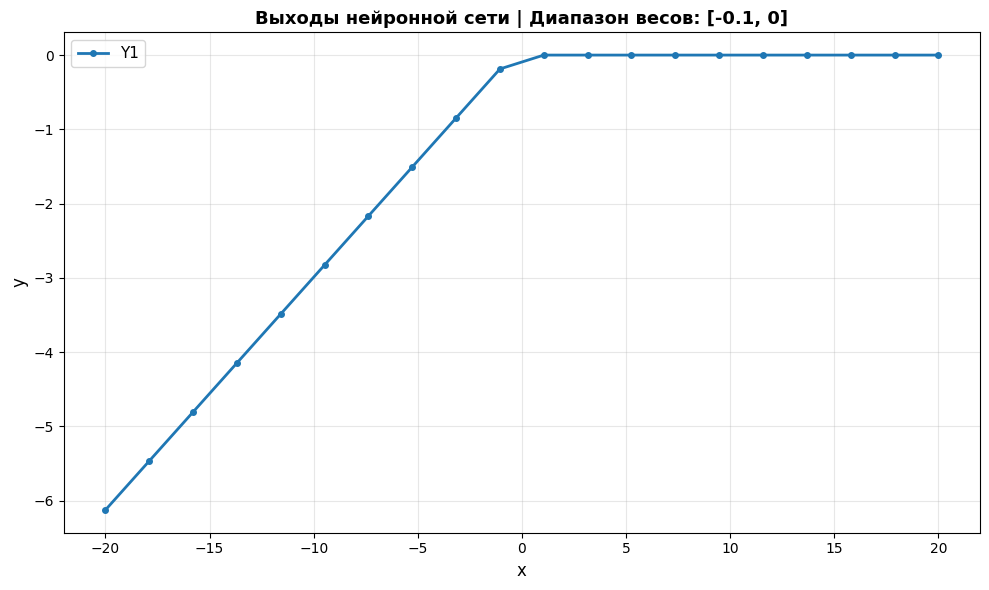

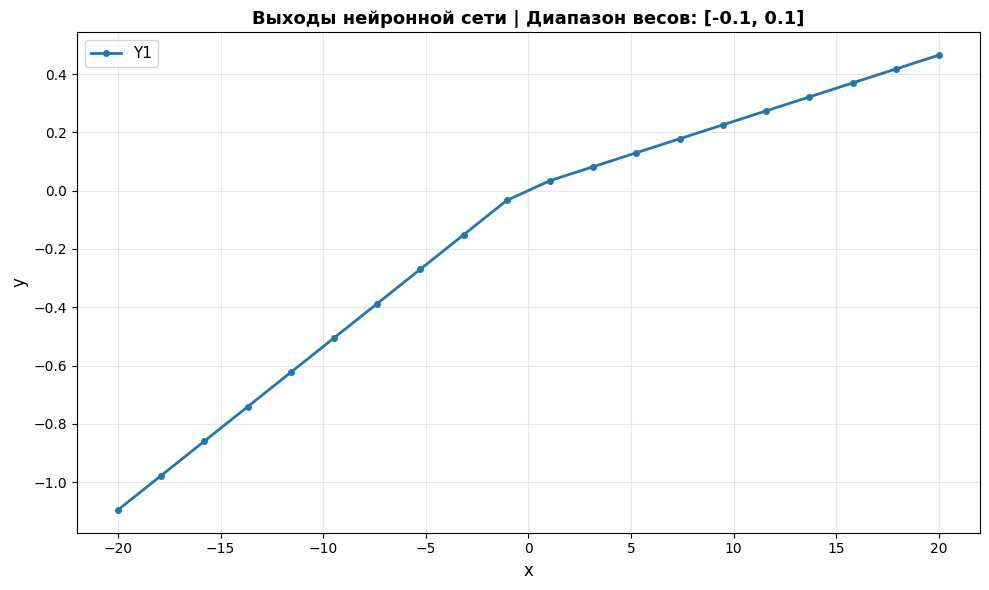

In [18]:
# Уменьшение весов в 10 раз
Wes(Xx, vx, a/10, b/10) # Дописать код
plt.show()

**Вывод:** При уменьшении весов в 10 раз выходные кривые становятся значительно более сглаженными и почти линейными. Амплитуда изменений уменьшается, а значения выходов слабо отклоняются от среднего уровня. Нейроны работают в области малых аргументов функции активации, поэтому нелинейность выражена слабо. Сеть становится менее чувствительной к изменениям входных данных.

#### 3.3.3. Эксперимент с увеличением весов в 10 раз

Запустите код ниже. Веса увеличатся в 10 раз (диапазоны $[-10; 0]$, $[-10; 10]$, $[0; 10]$).

Обратите внимание, как меняется характер кривых в зависимости от изменения весов. Напишите вывод.


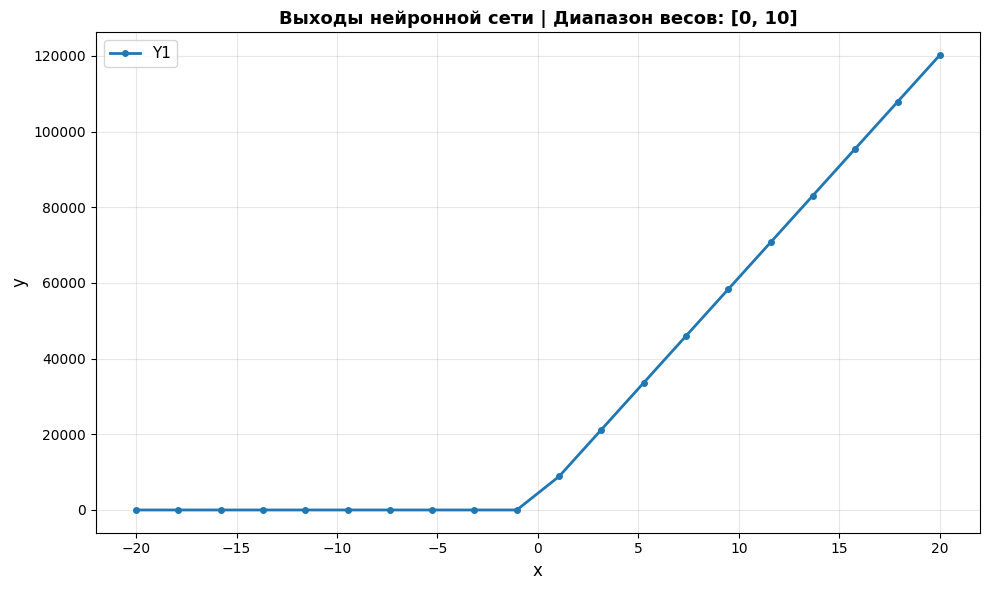

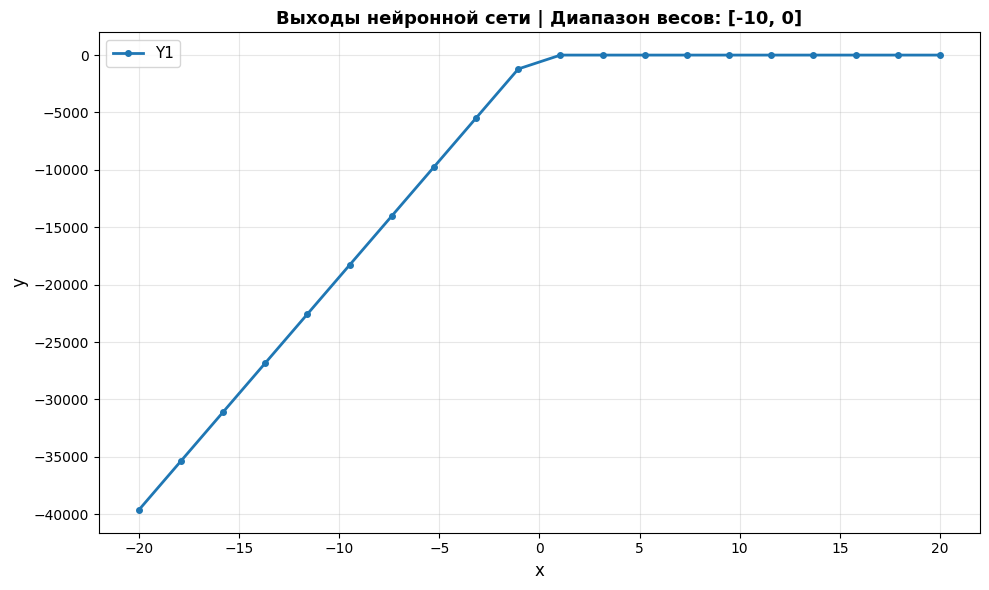

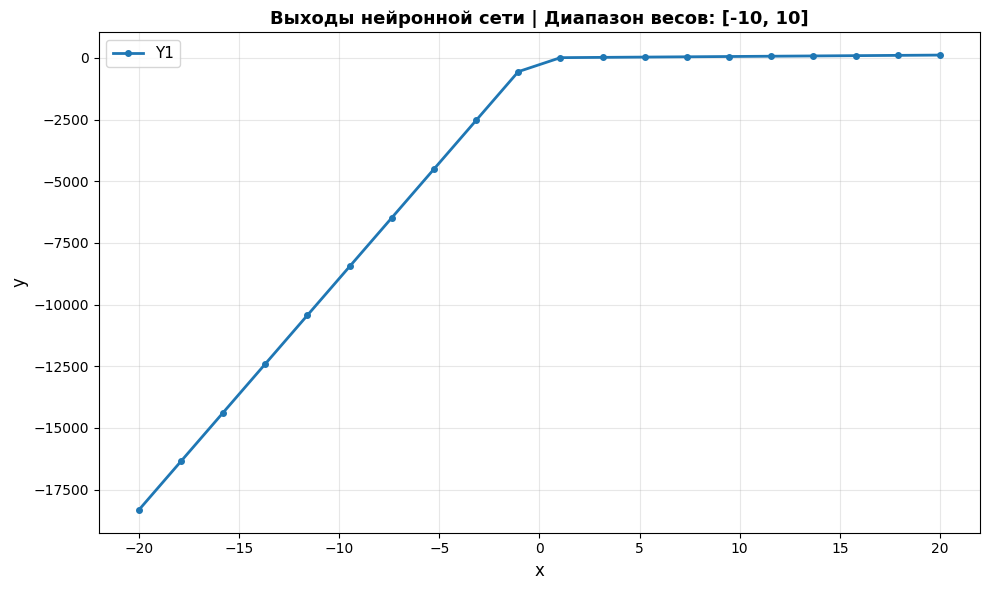

In [19]:
# Увеличение весов в 10 раз
Wes(Xx, vx, a*10, b*10) # Дописать код
plt.show()

**Вывод:** При увеличении весов в 10 раз выходные сигналы становятся более резкими и быстро переходят в режим насыщения. Функция активации работает в области больших аргументов, поэтому выходы стремятся к предельным значениям (например, близким к 0 или 1 для сигмоиды). Переходные участки становятся очень крутыми. Сеть становится чрезмерно чувствительной к малым изменениям входа.

### 4. Общий вывод

Диапазон начальных весов существенно влияет на характер выходных сигналов нейронной сети. Малые веса делают поведение сети почти линейным и сглаженным, большие - приводят к насыщению и резким переходам. Знак весов определяет направление изменения выходов. Оптимальный диапазон весов должен обеспечивать баланс между чувствительностью и стабильностью работы сети.

### 5. Контрольные вопросы

1.  **Понятие нейрона. Его математическая модель.** Искусственный нейрон состоит из трех основных блоков: набор входов (синапсов) с весовыми коэффициентами, сумматор (вычисляет взвешенную сумму входов) и функция активации (преобразует сумму в выходной сигнал). Математическая модель: $y = f(\sum_{i=1}^n w_i x_i + b)$, где $x_i$ — входы, $w_i$ — веса, $b$ — смещение (bias), $f$ — функция активации.
2.  **Нейронная сеть.** Нейронная сеть — это совокупность соединенных между собой искусственных нейронов, организованных в слои. Объединение нейронов необходимо для решения сложных задач, так как один нейрон способен распознавать только простейшие линейные закономерности, а сеть из нейронов может моделировать нелинейные зависимости любой сложности.
3.  **Свойства сигмоидальной функции активации.** Сигмоида популярна потому, что она: (1) нелинейна, (2) дифференцируема,(3) сжимает входной сигнал в диапазон (0, 1), что удобно интерпретировать как вероятность. Диапазон значений: от 0 до 1.
4.  **Области применения НС.** Нейросети превосходят обычные алгоритмы в: Распознавании и классификации изображений (компьютерное зрение); Обработке естественного языка (машинный перевод, чат-боты); Прогнозировании временных рядов (финансовые рынки, погода).
5.  **Однослойные и многослойные НС.** Однослойные сети (персептроны) способны решать только линейно разделимые задачи (например, логическое "И" или "ИЛИ"). Многослойные сети (с одним или несколькими скрытыми слоями) могут решать любые задачи, включая нелинейно разделимые (например, "исключающее ИЛИ" — XOR), благодаря способности выделять иерархии признаков.
6.  **Линейность vs Нелинейность.** Линейная функция активации (например, $f(x)=x$) делает всю сеть линейной, независимо от количества слоев - сложные зависимости моделироваться не будут. Нелинейная функция (сигмоида, ReLU) позволяет сети аппроксимировать любые сложные функции. Для решения реальных задач необходима нелинейность, так как большинство зависимостей в данных (изображения, речь, тексты) являются нелинейными.